# Cancer Prediction Using Gene Expression Data

Gene expression data contains information about the activity levels of genes within biological samples. Machine learning techniques can analyze these patterns to classify different cancer types accurately.

This project uses Mutual Information for feature selection and a One-vs-Rest Random Forest classifier for cancer prediction.

In [96]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf

from sklearn.feature_selection import mutual_info_classif


from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import balanced_accuracy_score,f1_score,precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve,auc
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

**Reading Data**

In [68]:
file_url="https://github.com/vappiah/Machine-Learning-Tutorials/raw/main/datasets/cancer_gene_expression.zip"
dataframe=pd.read_csv(file_url)

In [69]:
print (dataframe.shape)

(801, 8001)


In [70]:
print(dataframe.columns[0:3])

Index(['gene_1', 'gene_2', 'gene_3'], dtype='object')


In [71]:
dataframe.columns[-1]

'Cancer_Type'

In [72]:
datanul=dataframe.isnull().sum()
g=[i for i in datanul if i>0]

print('columns with missing values:%d'%len(g))

columns with missing values:0


In [73]:
print(dataframe['Cancer_Type'].value_counts())


Cancer_Type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


<Axes: xlabel='Cancer_Type'>

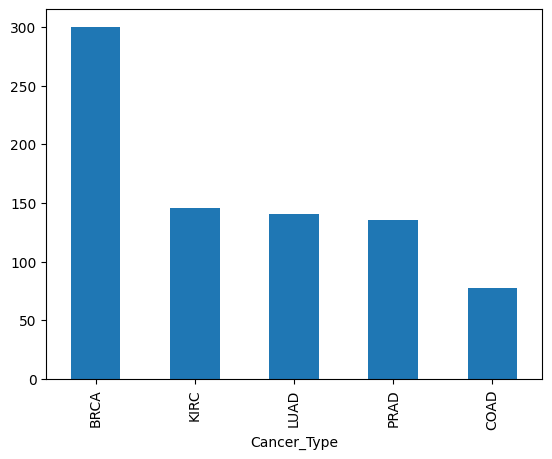

In [74]:
dataframe['Cancer_Type'].value_counts().plot.bar()

In [75]:
X=dataframe.iloc[:,0:-1]
y=dataframe.iloc[:,-1]

In [76]:
X.shape


(801, 8000)

In [77]:
y.shape

(801,)

In [78]:
label_encoder=LabelEncoder()
label_encoder.fit(y)
y_encoded=label_encoder.transform(y)
labels=label_encoder.classes_
classes=np.unique(y_encoded)

In [79]:
labels

array(['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD'], dtype=object)

In [80]:
classes

array([0, 1, 2, 3, 4])

**Data** **Splitting**

In [81]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,random_state=42)


In [82]:
dataframe.iloc[:,0:10].describe()


,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,gene_10
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,0.231049,0.010844,2.405459,0.005799,0.065640,0.022036,0.028394,0.703998,1.916364
std,0.136850,0.656692,0.153859,0.797236,0.052265,0.213557,0.148917,0.161606,0.779321,0.877010
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.898595,0.000000,0.000000,0.000000,0.000000,0.000000,1.357214
50%,0.000000,0.000000,0.000000,2.358284,0.000000,0.000000,0.000000,0.000000,0.518031,1.877862
75%,0.000000,0.000000,0.000000,2.929355,0.000000,0.000000,0.000000,0.000000,1.123931,2.486792
max,1.482332,6.575004,3.778061,4.746646,0.570754,1.866275,2.169925,2.375957,4.541670,4.932231


**Data Normalization**

In [83]:
min_max_scaler=MinMaxScaler()
X_train_norm=min_max_scaler.fit_transform(X_train)
X_train_norm=min_max_scaler.fit_transform(X_train)
X_test_norm=min_max_scaler.transform(X_test)


**Feature Selection**

In [84]:

MI=mutual_info_classif(X_train_norm,y_train)

In [85]:
n_features=300
selected_scores_indices=np.argsort(MI)[::-1][0:n_features]

In [86]:

X_train_selected=X_train_norm[:,selected_scores_indices]
X_test_selected=X_test_norm[:,selected_scores_indices]

In [87]:

X_train_selected.shape

(640, 300)

In [88]:
X_test_selected.shape


(161, 300)

**Classification**

In [89]:
RF=OneVsRestClassifier(RandomForestClassifier(max_features=0.2))
RF.fit(X_train_selected,y_train)
y_pred =RF.predict(X_test_selected)
pred_prob = RF.predict_proba(X_test_selected)

In [90]:
#accuracy
accuracy=np.round(balanced_accuracy_score(y_test,y_pred),4)
print('accuracy:%0.4f'%accuracy)

#precision
precision=np.round(precision_score(y_test,y_pred,average = 'weighted'),4)
print('precision:%0.4f'%precision)

#recall
recall=np.round(recall_score(y_test,y_pred,average = 'weighted'),4)
print('recall:%0.4f'%recall)

#f1score
f1score=np.round(f1_score(y_test,y_pred,average = 'weighted'),4)
print('f1score:%0.4f'%f1score)


report=classification_report(y_test,y_pred, target_names=labels)
print('\n')
print('classification report\n\n')
print(report)

accuracy:0.9667
precision:0.9818
recall:0.9814
f1score:0.9811


classification report


              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98        60
        COAD       1.00      0.88      0.93        16
        KIRC       1.00      1.00      1.00        28
        LUAD       0.96      0.96      0.96        24
        PRAD       1.00      1.00      1.00        33

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98       161



In [91]:
#generate confusion matrix
cm=confusion_matrix(y_test,y_pred)
cm_df=pd.DataFrame(cm,index=labels,columns=labels)

In [92]:
cm_df


,BRCA,COAD,KIRC,LUAD,PRAD
BRCA,60,0,0,0,0
COAD,1,14,0,1,0
KIRC,0,0,28,0,0
LUAD,1,0,0,23,0
PRAD,0,0,0,0,33


Text(50.722222222222214, 0.5, 'True Labels')

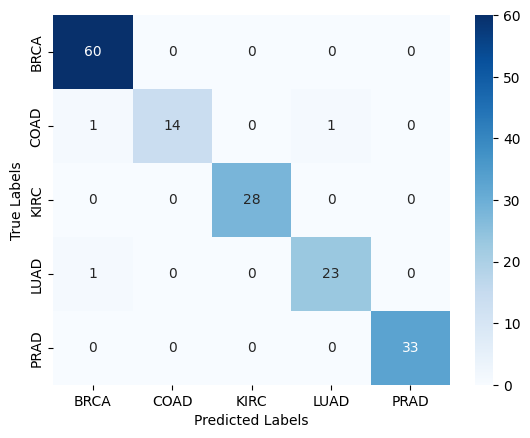

In [93]:

sns.heatmap(cm_df,annot=True,cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

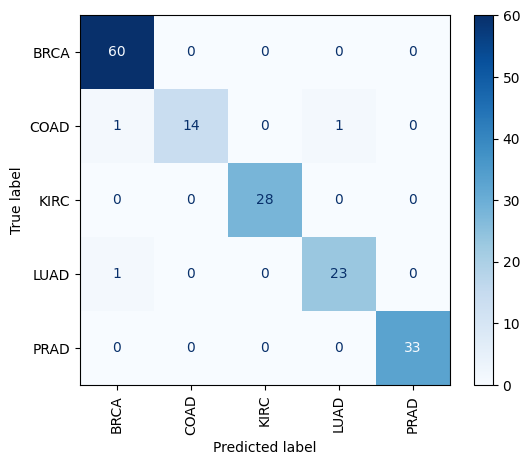

In [94]:
disp = ConfusionMatrixDisplay.from_estimator(
    RF,
    X_test_selected,
    y_test,
    cmap='Blues',
    display_labels=labels
)

plt.xticks(rotation='vertical')
plt.show()

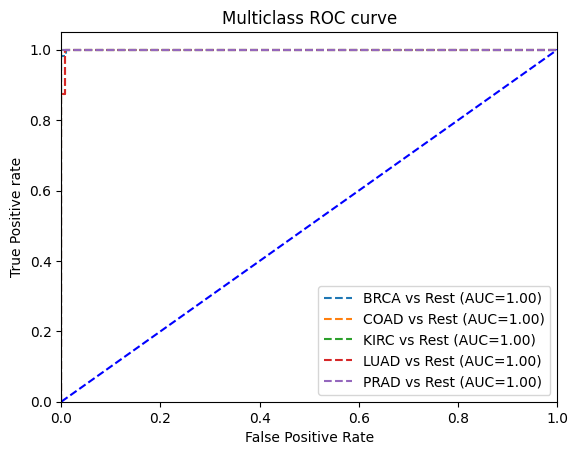

In [99]:
y_test_binarized=label_binarize(y_test,classes=classes)

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}
roc_auc = dict()

n_class = classes.shape[0]

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test_binarized[:,i], pred_prob[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    # plotting
    plt.plot(fpr[i], tpr[i], linestyle='--',
             label='%s vs Rest (AUC=%0.2f)'%(labels[i],roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

In [100]:
results = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1 Score'],
    'Value':[accuracy,precision,recall,f1score]
})

results

,Metric,Value
0,Accuracy,0.9667
1,Precision,0.9818
2,Recall,0.9814
3,F1 Score,0.9811


## Conclusion

This project successfully applied machine learning techniques to classify cancer types using gene expression data.

Mutual Information feature selection reduced dimensionality by selecting the most informative genes.

A One-vs-Rest Random Forest classifier achieved effective classification performance, demonstrating the usefulness of machine learning in cancer diagnosis and prediction.